# 08 - Conformal Prediction: Uncertainty Without a Model of the Noise

**Advanced Machine Learning** | Haydar Kilic

Notebook 04 produced error bars from a Gaussian likelihood; notebook 07 produced
none at all. Conformal prediction gives intervals with a **finite-sample,
distribution-free** guarantee that holds around *any* predictor.

Split the data into a training part and a calibration set of size $n$. Fit on
the first, score the second with a non-conformity measure $s_i$, and take

$$\hat q = s_{(\lceil (n+1)(1-\alpha)\rceil)} .$$

Then for an exchangeable new pair,

$$\mathbb{P}\bigl(y_{n+1} \in \mathcal{C}(x_{n+1})\bigr) \ge 1 - \alpha .$$

The proof needs only exchangeability: among $n+1$ exchangeable scores, the new
one exceeds the $\lceil(n+1)(1-\alpha)\rceil$-th with probability at most
$\alpha$. No Gaussianity, no correct model, no asymptotics.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np
from itertools import combinations_with_replacement
from dataclasses import dataclass, field

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_two_moons(n_samples=200, noise=0.2, random_state=None):
    """Two interleaving half circles -- the canonical non-linear 2-class toy."""
    rng = _rng(random_state)
    n_out = n_samples // 2
    n_in = n_samples - n_out
    t_out = np.linspace(0, np.pi, n_out)
    t_in = np.linspace(0, np.pi, n_in)
    outer = np.stack([np.cos(t_out), np.sin(t_out)], axis=1)
    inner = np.stack([1 - np.cos(t_in), 0.5 - np.sin(t_in)], axis=1)
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((n_samples, 2))
    y = np.hstack([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

def interval_coverage(y_true, lower, upper):
    """Empirical share of targets inside ``[lower, upper]``."""
    y_true = np.asarray(y_true, float)
    lower, upper = np.asarray(lower, float), np.asarray(upper, float)
    return float(np.mean((y_true >= lower) & (y_true <= upper)))

def interval_width(lower, upper):
    return float(np.mean(np.asarray(upper, float) - np.asarray(lower, float)))

# --- preprocessing -------------------------------------------------

class PolynomialFeatures:
    """Monomials up to ``degree`` (interactions included, bias excluded)."""

    def __init__(self, degree=2, include_bias=False):
        self.degree = int(degree)
        self.include_bias = include_bias

    def fit(self, X, y=None):
        n_features = np.asarray(X).shape[1]
        combos = []
        if self.include_bias:
            combos.append(())
        for d in range(1, self.degree + 1):
            combos.extend(combinations_with_replacement(range(n_features), d))
        self.combinations_ = combos
        return self

    def transform(self, X):
        X = np.asarray(X, float)
        cols = []
        for combo in self.combinations_:
            if not combo:
                cols.append(np.ones(len(X)))
            else:
                col = np.ones(len(X))
                for j in combo:
                    col = col * X[:, j]
                cols.append(col)
        return np.stack(cols, axis=1)

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

# --- linear --------------------------------------------------------

class _CenteredLinearModel:
    """Shared centring logic: fit on centred data, recover the intercept after."""

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = 0.0

    def _center(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if self.fit_intercept:
            self._x_mean = X.mean(axis=0)
            self._y_mean = y.mean()
            return X - self._x_mean, y - self._y_mean
        self._x_mean = np.zeros(X.shape[1])
        self._y_mean = 0.0
        return X, y

    def _set_intercept(self):
        self.intercept_ = float(self._y_mean - self._x_mean @ self.coef_)

    def predict(self, X):
        return np.asarray(X, float) @ self.coef_ + self.intercept_

class RidgeRegression(_CenteredLinearModel):
    r"""Ridge regression.

    Minimises :math:`\|y - Xw\|_2^2 + \alpha \|w\|_2^2`.  The SVD
    :math:`X = U D V^\top` gives the shrinkage form

    .. math:: \hat w = V \operatorname{diag}\!\left(\frac{d_j}{d_j^2+\alpha}\right) U^\top y,

    which also exposes the effective degrees of freedom
    :math:`\mathrm{df}(\alpha) = \sum_j d_j^2 / (d_j^2 + \alpha)`.
    """

    def __init__(self, alpha=1.0, fit_intercept=True):
        super().__init__(fit_intercept)
        self.alpha = float(alpha)

    def fit(self, X, y):
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        shrink = d / (d**2 + self.alpha)
        self.coef_ = Vt.T @ (shrink * (U.T @ yc))
        self.singular_values_ = d
        self.effective_dof_ = float(np.sum(d**2 / (d**2 + self.alpha)))
        self._set_intercept()
        return self

    def path(self, X, y, alphas):
        """Coefficient path over a grid of ``alphas`` (one row per alpha)."""
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        Uty = U.T @ yc
        return np.stack([Vt.T @ ((d / (d**2 + a)) * Uty) for a in alphas])

class LogisticRegression:
    r"""Binary logistic regression with an L2 penalty, solved by IRLS.

    Each Newton step solves the reweighted least-squares system

    .. math:: (X^\top S X + \lambda I)\,\Delta = X^\top (y - p) - \lambda w ,

    with :math:`S = \operatorname{diag}(p(1-p))`.  A small ridge term on the
    Hessian keeps the step well defined under separable data.
    """

    def __init__(self, C=1.0, max_iter=100, tol=1e-8, fit_intercept=True):
        self.C = float(C)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = 0.0
        self.loss_history_ = []

    def _design(self, X):
        X = np.asarray(X, float)
        if self.fit_intercept:
            return np.hstack([np.ones((len(X), 1)), X])
        return X

    def fit(self, X, y):
        Z = self._design(X)
        y = np.asarray(y, float)
        n, p = Z.shape
        lam = 1.0 / self.C
        penalty = np.full(p, lam)
        if self.fit_intercept:
            penalty[0] = 0.0  # never shrink the intercept
        w = np.zeros(p)
        self.loss_history_ = []
        for _ in range(self.max_iter):
            eta = Z @ w
            prob = _sigmoid(eta)
            grad = Z.T @ (y - prob) - penalty * w
            s = np.clip(prob * (1 - prob), 1e-10, None)
            H = (Z * s[:, None]).T @ Z + np.diag(penalty) + 1e-10 * np.eye(p)
            step = np.linalg.solve(H, grad)
            w = w + step
            self.loss_history_.append(self._nll(Z, y, w, penalty))
            if np.max(np.abs(step)) < self.tol:
                break
        if self.fit_intercept:
            self.intercept_, self.coef_ = float(w[0]), w[1:]
        else:
            self.intercept_, self.coef_ = 0.0, w
        return self

    @staticmethod
    def _nll(Z, y, w, penalty):
        eta = Z @ w
        # log(1+exp(eta)) computed stably
        ll = np.sum(y * eta - np.logaddexp(0.0, eta))
        return float(-ll + 0.5 * np.sum(penalty * w**2))

    def decision_function(self, X):
        return np.asarray(X, float) @ self.coef_ + self.intercept_

    def predict_proba(self, X):
        p = _sigmoid(self.decision_function(X))
        return np.stack([1 - p, p], axis=1)

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)

# --- trees ---------------------------------------------------------

@dataclass
class _Node:
    value: float = 0.0
    feature: int = -1
    threshold: float = 0.0
    gain: float = 0.0
    left: _Node | None = field(default=None, repr=False)
    right: _Node | None = field(default=None, repr=False)
    n_samples: int = 0

    @property
    def is_leaf(self):
        return self.left is None

class GradientTree:
    """Regression tree fitted to gradient/Hessian pairs."""

    def __init__(self, max_depth=3, min_samples_leaf=1, min_child_weight=1e-3,
                 reg_lambda=1.0, gamma=0.0, max_features=None, random_state=None):
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_child_weight = float(min_child_weight)
        self.reg_lambda = float(reg_lambda)
        self.gamma = float(gamma)
        self.max_features = max_features
        self.random_state = random_state

    # ------------------------------------------------------------ utilities
    def _leaf_value(self, g_sum, h_sum):
        return float(-g_sum / (h_sum + self.reg_lambda))

    def _objective(self, g_sum, h_sum):
        return float(g_sum**2 / (h_sum + self.reg_lambda))

    def _feature_subset(self, n_features, rng):
        if self.max_features is None:
            return np.arange(n_features)
        if isinstance(self.max_features, float):
            k = max(1, int(round(self.max_features * n_features)))
        else:
            k = min(int(self.max_features), n_features)
        return rng.choice(n_features, size=k, replace=False)

    # ------------------------------------------------------------- building
    def _best_split(self, X, g, h, rng):
        n, n_features = X.shape
        G, H = g.sum(), h.sum()
        parent = self._objective(G, H)
        best = (0.0, -1, 0.0)  # gain, feature, threshold

        for j in self._feature_subset(n_features, rng):
            order = np.argsort(X[:, j], kind="mergesort")
            xs, gs, hs = X[order, j], g[order], h[order]
            g_cum, h_cum = np.cumsum(gs)[:-1], np.cumsum(hs)[:-1]
            # only positions where the value actually changes are valid splits
            valid = xs[:-1] < xs[1:]
            if not valid.any():
                continue
            left_count = np.arange(1, n)
            valid &= (left_count >= self.min_samples_leaf)
            valid &= ((n - left_count) >= self.min_samples_leaf)
            valid &= (h_cum >= self.min_child_weight)
            valid &= ((H - h_cum) >= self.min_child_weight)
            if not valid.any():
                continue

            gain = 0.5 * (
                g_cum**2 / (h_cum + self.reg_lambda)
                + (G - g_cum) ** 2 / (H - h_cum + self.reg_lambda)
                - parent
            ) - self.gamma
            gain = np.where(valid, gain, -np.inf)
            idx = int(np.argmax(gain))
            if gain[idx] > best[0]:
                best = (float(gain[idx]), int(j), float(0.5 * (xs[idx] + xs[idx + 1])))
        return best

    def _build(self, X, g, h, depth, rng):
        node = _Node(value=self._leaf_value(g.sum(), h.sum()), n_samples=len(X))
        if depth >= self.max_depth or len(X) < 2 * self.min_samples_leaf:
            return node
        gain, feature, threshold = self._best_split(X, g, h, rng)
        if feature < 0 or gain <= 0.0:
            return node
        mask = X[:, feature] <= threshold
        if mask.all() or (~mask).all():
            return node
        node.feature, node.threshold, node.gain = feature, threshold, gain
        self.feature_importances_[feature] += gain
        node.left = self._build(X[mask], g[mask], h[mask], depth + 1, rng)
        node.right = self._build(X[~mask], g[~mask], h[~mask], depth + 1, rng)
        return node

    def fit(self, X, g, h=None):
        X = np.asarray(X, float)
        g = np.asarray(g, float)
        h = np.ones_like(g) if h is None else np.asarray(h, float)
        self.feature_importances_ = np.zeros(X.shape[1])
        rng = np.random.default_rng(self.random_state)
        self.root_ = self._build(X, g, h, 0, rng)
        return self

    # ------------------------------------------------------------ inference
    def predict(self, X):
        X = np.asarray(X, float)
        out = np.empty(len(X))
        for i, row in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                node = node.left if row[node.feature] <= node.threshold else node.right
            out[i] = node.value
        return out

    @property
    def n_leaves_(self):
        def count(node):
            return 1 if node.is_leaf else count(node.left) + count(node.right)

        return count(self.root_)

    @property
    def depth_(self):
        def depth(node):
            return 0 if node.is_leaf else 1 + max(depth(node.left), depth(node.right))

        return depth(self.root_)

# --- ensemble ------------------------------------------------------

class SquaredError:
    name = "squared_error"

    def init_prediction(self, y):
        return float(np.mean(y))

    def gradients(self, y, f):
        return f - y, np.ones_like(y)

    def loss(self, y, f):
        return float(np.mean(0.5 * (y - f) ** 2))

class AbsoluteError:
    """L1 loss: constant Hessian turns the Newton step into a gradient step."""

    name = "absolute_error"

    def init_prediction(self, y):
        return float(np.median(y))

    def gradients(self, y, f):
        return -np.sign(y - f), np.ones_like(y)

    def loss(self, y, f):
        return float(np.mean(np.abs(y - f)))

class LogisticLoss:
    name = "logistic"

    def init_prediction(self, y):
        p = float(np.clip(np.mean(y), 1e-6, 1 - 1e-6))
        return float(np.log(p / (1 - p)))

    def gradients(self, y, f):
        p = _sigmoid(f)
        return p - y, np.clip(p * (1 - p), 1e-6, None)

    def loss(self, y, f):
        return float(np.mean(np.logaddexp(0.0, f) - y * f))

_LOSSES = {
    "squared_error": SquaredError,
    "absolute_error": AbsoluteError,
    "logistic": LogisticLoss,
}

def _sigmoid(z):
    return np.where(z >= 0, 1.0 / (1.0 + np.exp(-np.abs(z))),
                    np.exp(-np.abs(z)) / (1.0 + np.exp(-np.abs(z))))

class _BaseGradientBoosting:
    def __init__(self, loss="squared_error", n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_samples_leaf=1, min_child_weight=1e-3, reg_lambda=1.0,
                 gamma=0.0, subsample=1.0, colsample=None, validation_fraction=0.0,
                 n_iter_no_change=10, tol=1e-6, random_state=None):
        self.loss = loss
        self.n_estimators = int(n_estimators)
        self.learning_rate = float(learning_rate)
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_child_weight = float(min_child_weight)
        self.reg_lambda = float(reg_lambda)
        self.gamma = float(gamma)
        self.subsample = float(subsample)
        self.colsample = colsample
        self.validation_fraction = float(validation_fraction)
        self.n_iter_no_change = int(n_iter_no_change)
        self.tol = float(tol)
        self.random_state = random_state

    def _make_loss(self):
        if isinstance(self.loss, str):
            return _LOSSES[self.loss]()
        return self.loss

    def _fit_raw(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        rng = np.random.default_rng(self.random_state)
        loss_fn = self._make_loss()

        if self.validation_fraction > 0.0:
            n_val = max(1, int(round(self.validation_fraction * len(X))))
            perm = rng.permutation(len(X))
            val_idx, train_idx = perm[:n_val], perm[n_val:]
            X_val, y_val = X[val_idx], y[val_idx]
            X, y = X[train_idx], y[train_idx]
        else:
            X_val = y_val = None

        n = len(X)
        self.init_ = loss_fn.init_prediction(y)
        f = np.full(n, self.init_)
        f_val = None if X_val is None else np.full(len(X_val), self.init_)

        self.estimators_ = []
        self.train_loss_ = []
        self.validation_loss_ = []
        self.feature_importances_ = np.zeros(X.shape[1])
        best_val, best_iter, since_improve = np.inf, 0, 0

        for _ in range(self.n_estimators):
            g, h = loss_fn.gradients(y, f)
            if self.subsample < 1.0:
                m = max(2, int(round(self.subsample * n)))
                rows = rng.choice(n, size=m, replace=False)
            else:
                rows = np.arange(n)

            tree = GradientTree(
                max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf,
                min_child_weight=self.min_child_weight, reg_lambda=self.reg_lambda,
                gamma=self.gamma, max_features=self.colsample,
                random_state=int(rng.integers(0, 2**31 - 1)),
            )
            tree.fit(X[rows], g[rows], h[rows])
            self.estimators_.append(tree)
            self.feature_importances_ += tree.feature_importances_

            f += self.learning_rate * tree.predict(X)
            self.train_loss_.append(loss_fn.loss(y, f))

            if X_val is not None:
                f_val += self.learning_rate * tree.predict(X_val)
                val_loss = loss_fn.loss(y_val, f_val)
                self.validation_loss_.append(val_loss)
                if val_loss < best_val - self.tol:
                    best_val, best_iter, since_improve = val_loss, len(self.estimators_), 0
                else:
                    since_improve += 1
                    if since_improve >= self.n_iter_no_change:
                        self.estimators_ = self.estimators_[:best_iter]
                        break

        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ = self.feature_importances_ / total
        self.n_estimators_ = len(self.estimators_)
        return self

    def _decision_raw(self, X):
        X = np.asarray(X, float)
        f = np.full(len(X), self.init_)
        for tree in self.estimators_:
            f += self.learning_rate * tree.predict(X)
        return f

    def staged_decision_raw(self, X):
        """Yield the running prediction after each boosting round."""
        X = np.asarray(X, float)
        f = np.full(len(X), self.init_)
        for tree in self.estimators_:
            f = f + self.learning_rate * tree.predict(X)
            yield f.copy()

class GradientBoostingRegressor(_BaseGradientBoosting):
    def fit(self, X, y):
        return self._fit_raw(X, y)

    def predict(self, X):
        return self._decision_raw(X)

    def staged_predict(self, X):
        yield from self.staged_decision_raw(X)

# --- conformal -----------------------------------------------------

def conformal_quantile(scores, alpha):
    r"""The :math:`\lceil (n+1)(1-\alpha)\rceil / n` empirical quantile."""
    scores = np.sort(np.asarray(scores, float))
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    if k > n:
        return float("inf")  # calibration set too small for this alpha
    return float(scores[k - 1])

class SplitConformalRegressor:
    """Conformal intervals around any point predictor.

    Parameters
    ----------
    model
        Fitted or unfitted regressor exposing ``fit``/``predict``.
    alpha
        Target miscoverage, e.g. ``0.1`` for 90% intervals.
    normalizer
        Optional regressor fitted to the calibration residual magnitudes; it
        turns the constant-width band into a locally adaptive one via the score
        :math:`s_i = |y_i - \\hat\\mu(x_i)| / (\\hat\\sigma(x_i) + \\epsilon)`.
    """

    def __init__(self, model, alpha=0.1, normalizer=None, eps=1e-6):
        self.model = model
        self.alpha = float(alpha)
        self.normalizer = normalizer
        self.eps = float(eps)

    def fit(self, X_train, y_train, X_calib, y_calib, refit=True):
        if refit:
            self.model.fit(X_train, y_train)
        residuals = np.abs(np.asarray(y_calib, float) - self.model.predict(X_calib))

        if self.normalizer is not None:
            train_res = np.abs(np.asarray(y_train, float) - self.model.predict(X_train))
            self.normalizer.fit(X_train, np.log(train_res + self.eps))
            sigma = np.exp(self.normalizer.predict(X_calib)) + self.eps
            scores = residuals / sigma
        else:
            scores = residuals

        self.calibration_scores_ = scores
        self.q_hat_ = conformal_quantile(scores, self.alpha)
        return self

    def predict(self, X, return_interval=True):
        center = self.model.predict(X)
        if not return_interval:
            return center
        if self.normalizer is not None:
            width = self.q_hat_ * (np.exp(self.normalizer.predict(X)) + self.eps)
        else:
            width = np.full(len(center), self.q_hat_)
        return center, center - width, center + width

class ConformalClassifier:
    """Prediction *sets* with a coverage guarantee.

    ``score="lac"`` uses :math:`s = 1 - \\hat p_y` (smallest sets on average);
    ``score="aps"`` accumulates sorted probabilities until the true label is
    reached, which behaves better for conditional coverage.
    """

    def __init__(self, model, alpha=0.1, score="lac"):
        self.model = model
        self.alpha = float(alpha)
        self.score = score

    def _scores(self, proba, y_idx):
        if self.score == "lac":
            return 1.0 - proba[np.arange(len(y_idx)), y_idx]
        if self.score == "aps":
            order = np.argsort(-proba, axis=1)
            sorted_p = np.take_along_axis(proba, order, axis=1)
            cumulative = np.cumsum(sorted_p, axis=1)
            rank = np.argmax(order == y_idx[:, None], axis=1)
            return cumulative[np.arange(len(y_idx)), rank]
        raise ValueError("score must be 'lac' or 'aps'.")

    def fit(self, X_train, y_train, X_calib, y_calib, refit=True):
        if refit:
            self.model.fit(X_train, y_train)
        self.classes_ = np.asarray(getattr(self.model, "classes_", np.unique(y_train)))
        proba = self.model.predict_proba(X_calib)
        y_idx = np.searchsorted(self.classes_, np.asarray(y_calib))
        self.calibration_scores_ = self._scores(proba, y_idx)
        self.q_hat_ = conformal_quantile(self.calibration_scores_, self.alpha)
        return self

    def predict_set(self, X):
        """Boolean mask of shape ``(n_samples, n_classes)``."""
        proba = self.model.predict_proba(X)
        if self.score == "lac":
            return (1.0 - proba) <= self.q_hat_
        order = np.argsort(-proba, axis=1)
        sorted_p = np.take_along_axis(proba, order, axis=1)
        cumulative = np.cumsum(sorted_p, axis=1)
        # keep exactly the labels whose calibration score is below the threshold
        # (the non-randomised variant, so coverage is slightly conservative)
        include_sorted = cumulative <= self.q_hat_
        include_sorted[:, 0] = True  # never return an empty set
        mask = np.zeros_like(include_sorted)
        np.put_along_axis(mask, order, include_sorted, axis=1)
        return mask

    def coverage(self, X, y):
        mask = self.predict_set(X)
        y_idx = np.searchsorted(self.classes_, np.asarray(y))
        return float(np.mean(mask[np.arange(len(y_idx)), y_idx]))

    def average_set_size(self, X):
        return float(self.predict_set(X).sum(axis=1).mean())

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

In [2]:
plt = set_style()


def heteroscedastic(n, random_state):
    """y = 3 sin(x) + noise whose scale grows with x."""
    rng = np.random.default_rng(random_state)
    X = rng.uniform(0, 4, size=(n, 1))
    y = 3 * np.sin(X[:, 0]) + (0.1 + 0.6 * X[:, 0]) * rng.standard_normal(n)
    return X, y


X, y = heteroscedastic(3000, random_state=0)
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.7, random_state=1)
X_calib, X_test, y_calib, y_test = train_test_split(X_rest, y_rest, test_size=0.5,
                                                    random_state=2)
print(f"train {len(X_train)} | calibration {len(X_calib)} | test {len(X_test)}")

train 900 | calibration 1050 | test 1050


## 1. The calibration step, in full

With absolute residuals as the score, $s_i = |y_i - \hat\mu(x_i)|$, the interval
is $\hat\mu(x) \pm \hat q$. Everything hinges on one order statistic.

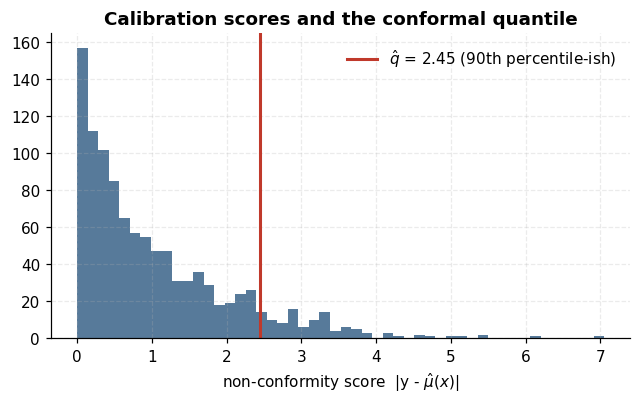

n = 1050, k = ceil((n+1)(1-alpha)) = 946, q_hat = 2.4527
fraction of calibration scores <= q_hat: 0.9010


In [3]:
poly = PolynomialFeatures(5)
Z_train, Z_calib, Z_test = (poly.fit_transform(X_train), poly.transform(X_calib),
                            poly.transform(X_test))

cp = SplitConformalRegressor(RidgeRegression(alpha=1.0), alpha=0.1)
cp.fit(Z_train, y_train, Z_calib, y_calib)
scores = cp.calibration_scores_

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.hist(scores, bins=50, color=PALETTE[0], alpha=0.75)
ax.axvline(cp.q_hat_, color=PALETTE[1], lw=2,
           label=fr"$\hat q$ = {cp.q_hat_:.2f} (90th percentile-ish)")
ax.set_xlabel("non-conformity score  |y - $\\hat\\mu(x)$|")
ax.set_title("Calibration scores and the conformal quantile")
ax.legend()
plt.show()

k = int(np.ceil((len(scores) + 1) * 0.9))
print(f"n = {len(scores)}, k = ceil((n+1)(1-alpha)) = {k}, "
      f"q_hat = {np.sort(scores)[k - 1]:.4f}")
print(f"fraction of calibration scores <= q_hat: {(scores <= cp.q_hat_).mean():.4f}")

## 2. Coverage is what it promises -- for any $\alpha$

The guarantee is *marginal*: averaged over the joint distribution of $(x, y)$.
We check it empirically across several miscoverage levels.

In [4]:
print(f"{'alpha':>7}{'target':>10}{'empirical':>12}{'mean width':>13}")
for alpha in [0.01, 0.05, 0.1, 0.2, 0.3]:
    fit = SplitConformalRegressor(RidgeRegression(alpha=1.0), alpha=alpha)
    fit.fit(Z_train, y_train, Z_calib, y_calib)
    _, lo, hi = fit.predict(Z_test)
    print(f"{alpha:>7.2f}{1 - alpha:>10.2f}{interval_coverage(y_test, lo, hi):>12.3f}"
          f"{interval_width(lo, hi):>13.3f}")

  alpha    target   empirical   mean width
   0.01      0.99       0.980        8.590
   0.05      0.95       0.940        6.354
   0.10      0.90       0.901        4.905
   0.20      0.80       0.818        3.570
   0.30      0.70       0.705        2.593


## 3. Marginal is not conditional

A constant-width band satisfies the guarantee *on average* while being far too
wide where the noise is small and too narrow where it is large. Normalising the
score by an estimate of the local scale,

$$s_i = \frac{|y_i - \hat\mu(x_i)|}{\hat\sigma(x_i)} ,$$

produces intervals that breathe with the data. We fit $\hat\sigma$ as a second
model on the log absolute residuals.

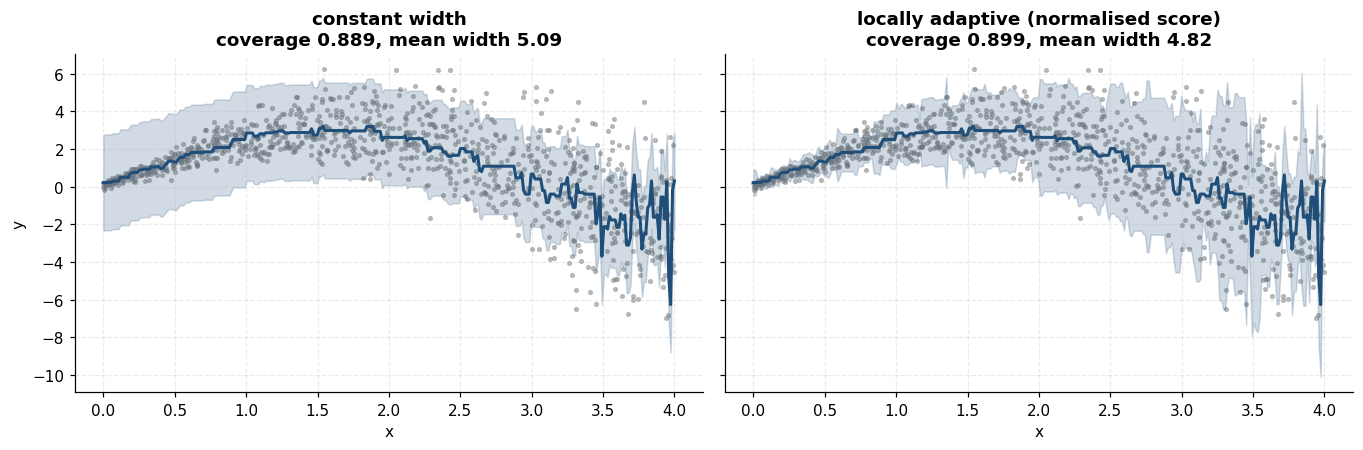

In [5]:
def booster():
    return GradientBoostingRegressor(n_estimators=120, max_depth=3, learning_rate=0.1,
                                     random_state=0)


plain = SplitConformalRegressor(booster(), alpha=0.1)
plain.fit(X_train, y_train, X_calib, y_calib)

adaptive = SplitConformalRegressor(booster(), alpha=0.1, normalizer=booster())
adaptive.fit(X_train, y_train, X_calib, y_calib)

grid = np.linspace(0, 4, 300).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, model, title in [(axes[0], plain, "constant width"),
                         (axes[1], adaptive, "locally adaptive (normalised score)")]:
    center, lo, hi = model.predict(grid)
    ax.scatter(X_test, y_test, s=6, color="grey", alpha=0.45)
    ax.plot(grid, center, color=PALETTE[0], lw=2)
    ax.fill_between(grid.ravel(), lo, hi, color=PALETTE[0], alpha=0.2)
    _, lo_t, hi_t = model.predict(X_test)
    ax.set_title(f"{title}\ncoverage {interval_coverage(y_test, lo_t, hi_t):.3f}, "
                 f"mean width {interval_width(lo_t, hi_t):.2f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

Both bands cover about 90% overall. The difference appears when we slice the
input space: the constant band massively over-covers where the noise is small
and pays for it elsewhere.

In [6]:
_, lo_p, hi_p = plain.predict(X_test)
_, lo_a, hi_a = adaptive.predict(X_test)
edges = [0, 1, 2, 3, 4]

print(f"{'x range':>10}{'plain cov':>12}{'plain width':>13}"
      f"{'adaptive cov':>15}{'adaptive width':>16}")
for lo_edge, hi_edge in zip(edges[:-1], edges[1:]):
    mask = (X_test[:, 0] >= lo_edge) & (X_test[:, 0] < hi_edge)
    print(f"{f'[{lo_edge},{hi_edge})':>10}"
          f"{interval_coverage(y_test[mask], lo_p[mask], hi_p[mask]):>12.3f}"
          f"{interval_width(lo_p[mask], hi_p[mask]):>13.2f}"
          f"{interval_coverage(y_test[mask], lo_a[mask], hi_a[mask]):>15.3f}"
          f"{interval_width(lo_a[mask], hi_a[mask]):>16.2f}")

   x range   plain cov  plain width   adaptive cov  adaptive width
     [0,1)       1.000         5.09          0.914            1.52
     [1,2)       0.992         5.09          0.913            3.60
     [2,3)       0.906         5.09          0.947            6.42
     [3,4)       0.678         5.09          0.832            7.62


## 4. Prediction *sets* for classification

The same recipe with $s = 1 - \hat p_y$ (least-ambiguous-set) returns a set of
labels rather than an interval. Where the model is confident the set is a
singleton; in the overlap region it contains both classes -- an explicit
"I don't know" that a top-1 prediction cannot express.

coverage        : 0.917  (target 0.90)
average set size: 1.187
singletons      : 0.813 of test points


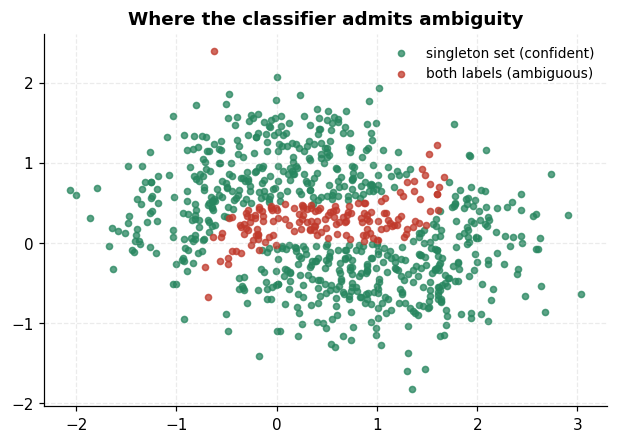

In [7]:
Xm, ym = make_two_moons(2400, noise=0.45, random_state=3)
Xm_tr, Xm_rest, ym_tr, ym_rest = train_test_split(Xm, ym, test_size=0.7, random_state=4)
Xm_cal, Xm_te, ym_cal, ym_te = train_test_split(Xm_rest, ym_rest, test_size=0.5,
                                                random_state=5)

poly3 = PolynomialFeatures(3)
Zm_tr, Zm_cal, Zm_te = (poly3.fit_transform(Xm_tr), poly3.transform(Xm_cal),
                        poly3.transform(Xm_te))

cc = ConformalClassifier(LogisticRegression(C=5.0), alpha=0.1, score="lac")
cc.fit(Zm_tr, ym_tr, Zm_cal, ym_cal)
sets = cc.predict_set(Zm_te)
sizes = sets.sum(axis=1)

print(f"coverage        : {cc.coverage(Zm_te, ym_te):.3f}  (target 0.90)")
print(f"average set size: {cc.average_set_size(Zm_te):.3f}")
print(f"singletons      : {(sizes == 1).mean():.3f} of test points")

fig, ax = plt.subplots(figsize=(6.6, 4.4))
for size, colour, label in [(1, PALETTE[2], "singleton set (confident)"),
                            (2, PALETTE[1], "both labels (ambiguous)")]:
    mask = sizes == size
    ax.scatter(Xm_te[mask, 0], Xm_te[mask, 1], s=16, color=colour, alpha=0.75, label=label)
ax.set_title("Where the classifier admits ambiguity")
ax.legend(loc="upper right", fontsize=9)
plt.show()

The ambiguous points concentrate exactly along the boundary between the two
moons, which is the behaviour we want: set size is an interpretable, per-point
difficulty measure.

## 5. Harder problems produce larger sets

In [8]:
print(f"{'label noise':>12}{'coverage':>11}{'avg set size':>14}")
for noise in [0.1, 0.3, 0.5, 0.7]:
    Xn, yn = make_two_moons(2000, noise=noise, random_state=6)
    Xn_tr, Xn_rest, yn_tr, yn_rest = train_test_split(Xn, yn, test_size=0.7, random_state=7)
    Xn_cal, Xn_te, yn_cal, yn_te = train_test_split(Xn_rest, yn_rest, test_size=0.5,
                                                    random_state=8)
    fit = ConformalClassifier(LogisticRegression(C=5.0), alpha=0.1)
    fit.fit(Xn_tr, yn_tr, Xn_cal, yn_cal)
    print(f"{noise:>12.1f}{fit.coverage(Xn_te, yn_te):>11.3f}"
          f"{fit.average_set_size(Xn_te):>14.3f}")

 label noise   coverage  avg set size
         0.1      0.886         1.029
         0.3      0.904         1.144
         0.5      0.901         1.229
         0.7      0.887         1.350


Coverage stays pinned at the target while the sets grow -- conformal prediction
never breaks its promise; it just becomes less informative, which is the honest
response to a harder problem.

## 6. The fine print

* **Exchangeability is required.** Under distribution shift or temporal
  dependence the guarantee fails; adaptive/online conformal variants exist for
  that case.
* **The guarantee is marginal.** Conditional coverage at every $x$ is impossible
  in general (Vovk, 2012; Foygel Barber et al., 2021); normalised scores,
  Mondrian/group-wise calibration and conformalised quantile regression are
  practical approximations.
* **Calibration data costs you.** Split conformal spends a slice of the data;
  cross-conformal and jackknife+ reuse it at greater computational cost.
* **The model still matters.** A poor predictor yields *valid but wide*
  intervals. Validity is free; sharpness is not.

## 7. What to take away

1. One order statistic on held-out scores converts any point predictor into a
   set predictor with finite-sample coverage.
2. Marginal validity is not conditional validity -- always slice the coverage.
3. The choice of non-conformity score determines how adaptive the output is; it
   is where the modelling effort belongs.
4. Set size is a per-instance difficulty signal, useful for triage and for
   routing hard cases to a human.

---
*End of the notebook series. Every notebook is self-contained: the toolkit cell
at the top holds the full implementation of the methods it discusses.*